<a href="https://colab.research.google.com/github/rishikarshetty60/nndl-open-ended-project/blob/main/nndl_project_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow matplotlib seaborn scikit-learn

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API setup completed!")

Kaggle API setup completed!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:16<00:00, 149MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/chest_xray"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    if "train" in dirs and "test" in dirs:
        print("Dataset path:", root)

Dataset path: /content/chest_xray/chest_xray
Dataset path: /content/chest_xray/chest_xray/__MACOSX/chest_xray
Dataset path: /content/chest_xray/chest_xray/chest_xray


In [ ]:
dataset_path = "/content/chest_xray/chest_xray"

In [ ]:
print(os.listdir(dataset_path))

['__MACOSX', 'val', 'train', 'test', 'chest_xray']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    dataset_path + "/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 349ms/step - accuracy: 0.8702 - loss: 0.3354 - val_accuracy: 0.9375 - val_loss: 0.2256
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 338ms/step - accuracy: 0.9479 - loss: 0.1430 - val_accuracy: 0.8750 - val_loss: 0.2347
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 347ms/step - accuracy: 0.9659 - loss: 0.1005 - val_accuracy: 0.7500 - val_loss: 0.5456
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.9728 - loss: 0.0781 - val_accuracy: 0.9375 - val_loss: 0.1329
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 328ms/step - accuracy: 0.9711 - loss: 0.0827 - val_accuracy: 0.9375 - val_loss: 0.2357
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 328ms/step - accuracy: 0.9797 - loss: 0.0582 - val_accuracy: 0.8125 - val_loss: 0.6552
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 325ms/step - accuracy: 0.9843 - loss: 0.0444 - val_accuracy: 0.8750 - val_loss: 0.4101
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 331ms/step - accuracy: 0.9837 - loss: 0

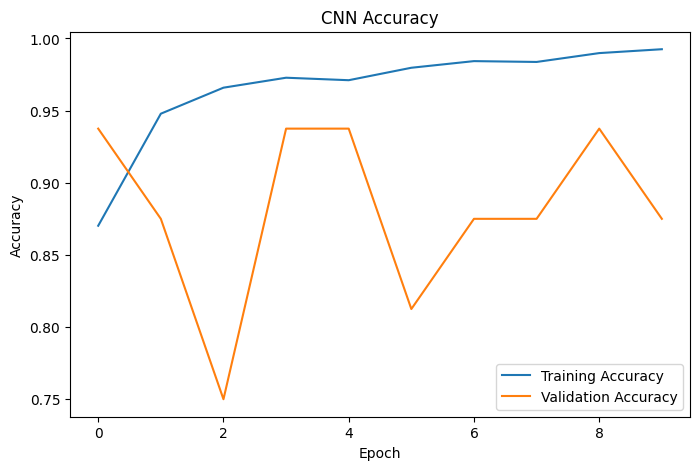

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")

plt.legend()
plt.show()

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
transfer_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_train = transfer_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

transfer_val = transfer_datagen.flow_from_directory(
    dataset_path + "/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
transfer_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_history = transfer_model.fit(
    transfer_train,
    validation_data=transfer_val,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 342ms/step - accuracy: 0.9337 - loss: 0.1676 - val_accuracy: 0.8750 - val_loss: 0.2494
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 309ms/step - accuracy: 0.9680 - loss: 0.0838 - val_accuracy: 0.8750 - val_loss: 0.2819
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 320ms/step - accuracy: 0.9747 - loss: 0.0695 - val_accuracy: 0.9375 - val_loss: 0.1067
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 318ms/step - accuracy: 0.9764 - loss: 0.0618 - val_accuracy: 0.9375 - val_loss: 0.1005
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 312ms/step - accuracy: 0.9808 - loss: 0.0535 - val_accuracy: 0.8750 - val_loss: 0.0983
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 313ms/step - accuracy: 0.9845 - loss: 0.0453 - val_accuracy: 0.8750 - val_loss: 0.1828
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 316ms/step - accuracy: 0.9820 - loss: 0.0437 - val_accuracy: 0.8750 - val_loss: 0.1797
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 310ms/step - accuracy: 0.9872 - loss: 0

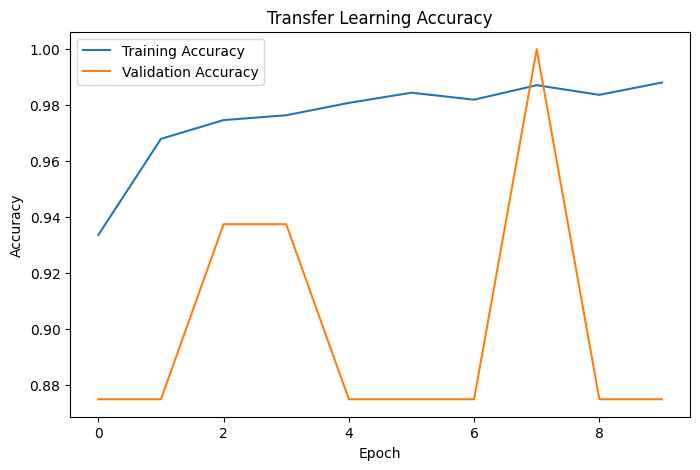

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")

plt.legend()
plt.show()

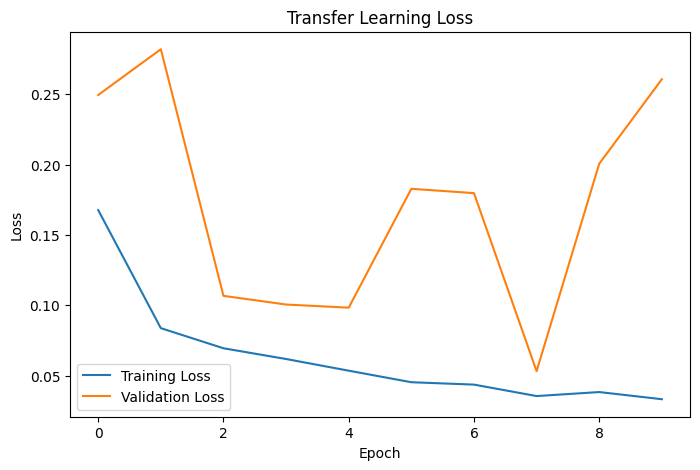

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

In [ ]:
test_data = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    dataset_path + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

cnn_loss, cnn_accuracy = cnn_model.evaluate(test_data)

print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.7324 - loss: 2.6714
CNN Test Accuracy: 0.7323718070983887
CNN Test Loss: 2.6714179515838623


In [ ]:
transfer_test = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    dataset_path + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

transfer_loss, transfer_accuracy = transfer_model.evaluate(
    transfer_test
)

print("Transfer Learning Test Accuracy:", transfer_accuracy)
print("Transfer Learning Test Loss:", transfer_loss)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.7949 - loss: 1.1270
Transfer Learning Test Accuracy: 0.7948718070983887
Transfer Learning Test Loss: 1.1269938945770264


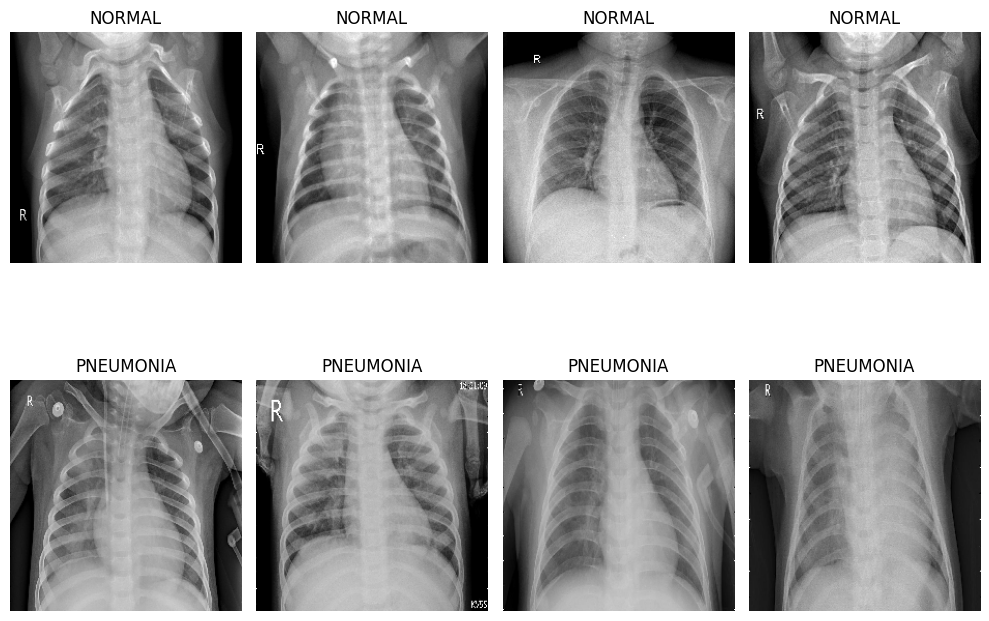

In [ ]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.utils import load_img

normal_path = dataset_path + "/train/NORMAL"
pneumonia_path = dataset_path + "/train/PNEUMONIA"

normal_images = os.listdir(normal_path)
pneumonia_images = os.listdir(pneumonia_path)

plt.figure(figsize=(10, 8))

# 4 NORMAL images
for i in range(4):
    img = load_img(
        os.path.join(normal_path, normal_images[i]),
        target_size=(224, 224)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

# 4 PNEUMONIA images
for i in range(4):
    img = load_img(
        os.path.join(pneumonia_path, pneumonia_images[i]),
        target_size=(224, 224)
    )

    plt.subplot(2, 4, i + 5)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
transfer_test.reset()

predictions = transfer_model.predict(transfer_test)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = transfer_test.classes

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 397ms/step
              precision    recall  f1-score   support

      NORMAL       0.99      0.46      0.63       234
   PNEUMONIA       0.75      1.00      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



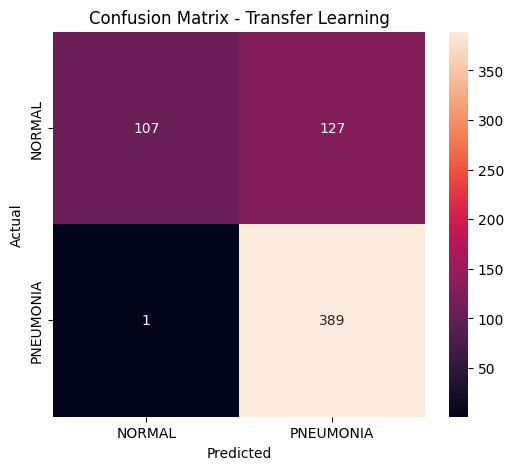

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Transfer Learning")

plt.show()

In [ ]:
print("====================================")
print("       MODEL COMPARISON")
print("====================================")

print("CNN Test Accuracy:")
print(cnn_accuracy)

print("\nTransfer Learning Test Accuracy:")
print(transfer_accuracy)

       MODEL COMPARISON
CNN Test Accuracy:
0.7323718070983887

Transfer Learning Test Accuracy:
0.7948718070983887
